<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/clase_12_mayo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        ANÁLISIS DE REGRESIÓN LINEAL - VUELOS AÉREOS
n=30 | α=0.05 | X=Distancia | Y=Tarifa (en dólares)

--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---
X: μ=1169.70, σ=750.49, rango=[177, 2521] (millas)
Y: μ=208.67, σ=60.27, rango=[109.0, 348.0] (dólares)

Normalidad (Shapiro-Wilk):
  X: p=0.0065 ✗ No normal
  Y: p=0.4226 ✓ Normal

Correlación: Pearson=0.6556 | Spearman=0.6037
Magnitud: Moderada | Dirección: Positiva

--- PRUEBA DE CORRELACIÓN ---
H₀: ρ=0 vs H₁: ρ≠0 | t=4.594, t_crit=±2.048, p=0.0001
Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA y positiva (ρ > 0).
   Es razonable concluir que el coeficiente de correlación es mayor a cero.

--- MODELO DE REGRESIÓN (Parte d) ---
Ecuación: Ŷ = 147.0812 + 0.0527X
  b₀ (intersección): 147.0812 → Tarifa base esperada (dólares) cuando la distancia es 0.
  b₁ (pendiente): 0.0527 → Por cada milla adicional, la tarifa aumenta en 0.0527 dólares.

Estimación de tarifa para un vuelo de 1,000 millas:
  Tarifa estimada para 1,000 millas: $19

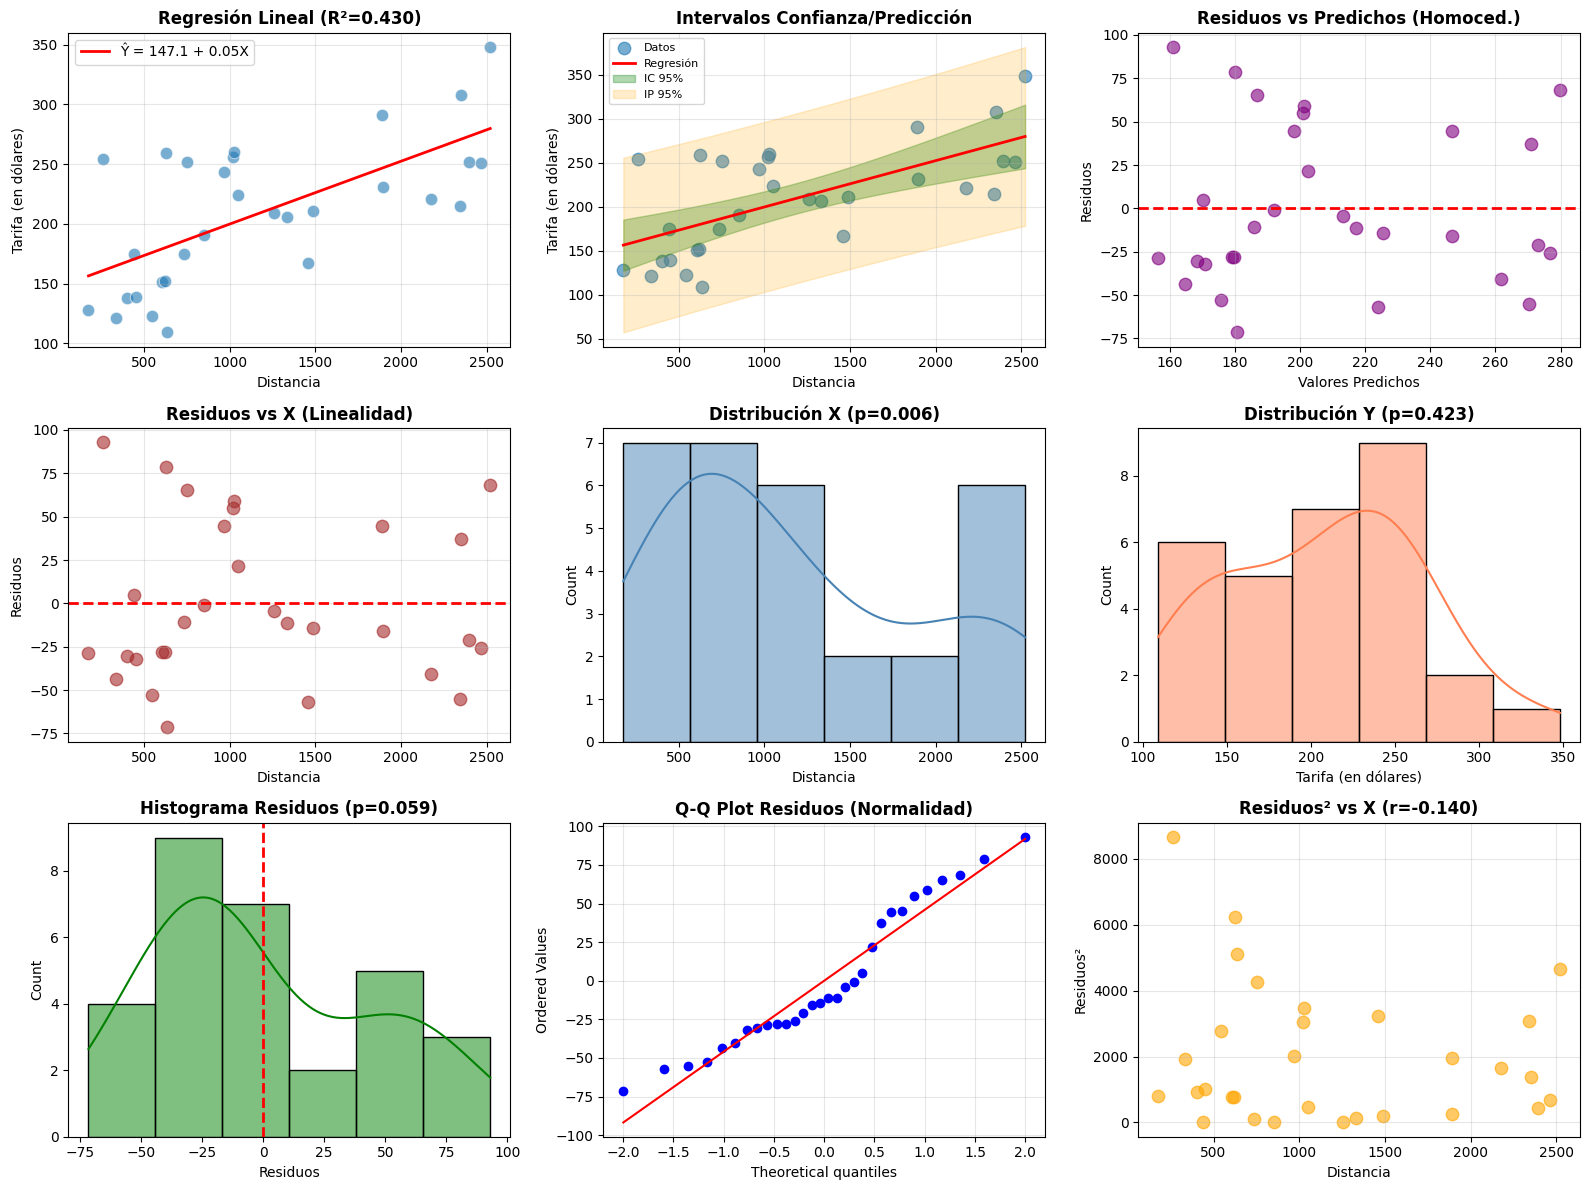


✓ ANÁLISIS COMPLETADO


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist, levene
from scipy import stats
import numpy as np

# --- DATOS DEL PROBLEMA (VUELOS AÉREOS) ---
data = {
    'Origen': ['Detroit, MI', 'Las Vegas, NV', 'Atlanta, GA', 'Chicago, IL', 'Fort Lauderdale, FL', 'Filadelfia, PA', 'Houston, TX', 'Baltimore, MD', 'Boston, MA', 'Kansas City, MO', 'Phoenix, AZ', 'Houston, TX', 'Burbank, CA', 'Atlanta, GA', 'Minneapolis, MN', 'Myrtle Beach, SC', 'Filadelfia, PA', 'Orlando, FL', 'Covington, KY', 'Los Ángeles, CA', 'Indianapolis, IN', 'San Francisco, CA', 'Columbus, OH', 'San Diego, CA', 'Washington, DC', 'St. Louis, MO', 'Seattle, WA', 'San Diego, CA', 'Nueva York, NY', 'Portland, ME'],
    'Destino': ['Baltimore, MD', 'Sacramento, CA', 'Boston, MA', 'Columbus, OH', 'Chicago, IL', 'Fort Lauderdale, FL', 'Houston, TX', 'Kansas City, MO', 'Milwaukee, WI', 'Portland, OR', 'Baltimore, MD', 'Houston, TX', 'Burbank, CA', 'Atlanta, GA', 'Minneapolis, MN', 'Nueva Orleans, LA', 'Myrtle Beach, SC', 'Sacramento, CA', 'Seattle, WA', 'Orlando, FL', 'Covington, KY', 'Los Ángeles, CA', 'Indianapolis, IN', 'San Francisco, CA', 'RaleighyDurham, NC', 'MidlandyOdessa, TX', 'DallasyFt.Worth, TX', 'Columbus, OH', 'San Diego, CA', 'Phoenix, AZ'],
    'Distancia': [636, 2395, 2176, 605, 403, 1258, 264, 627, 2342, 177, 2521, 1050, 441, 1021, 336, 752, 1333, 1460, 2350, 621, 737, 853, 1894, 2465, 1891, 1028, 545, 1489, 452, 969],
    'Tarifa (en dólares)': ['$109', '252', '221', '151', '138', '209', '254', '259', '215', '128', '348', '224', '175', '256', '121', '252', '206', '167', '308', '152', '175', '191', '231', '251', '291', '260', '123', '211', '139', '243']
}
df = pd.DataFrame(data)

# Limpiar y convertir la columna 'Tarifa (en dólares)' a numérica
df['Tarifa (en dólares)'] = df['Tarifa (en dólares)'].replace({r'\$': ''}, regex=True).astype(float)

var_x = 'Distancia'
var_y = 'Tarifa (en dólares)'
n, alfa = len(df), 0.05

print("=" * 70)
print("        ANÁLISIS DE REGRESIÓN LINEAL - VUELOS AÉREOS")
print("=" * 70)
print(f"n={n} | α={alfa} | X={var_x} | Y={var_y}\n")

# --- ANÁLISIS DESCRIPTIVO ---
mean_x, mean_y = df[var_x].mean(), df[var_y].mean()
std_x, std_y = df[var_x].std(ddof=1), df[var_y].std(ddof=1)
min_x, max_x = df[var_x].min(), df[var_x].max()
min_y, max_y = df[var_y].min(), df[var_y].max()

# Correlaciones y Normalidad
pearson = df[var_x].corr(df[var_y])
spearman = df[var_x].corr(df[var_y], method='spearman')
shapiro_x = shapiro(df[var_x])
shapiro_y = shapiro(df[var_y])

print("--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---")
print(f"X: μ={mean_x:.2f}, σ={std_x:.2f}, rango=[{min_x}, {max_x}] (millas)")
print(f"Y: μ={mean_y:.2f}, σ={std_y:.2f}, rango=[{min_y}, {max_y}] (dólares)")
print(f"\nNormalidad (Shapiro-Wilk):")
print(f"  X: p={shapiro_x.pvalue:.4f} {'✓ Normal' if shapiro_x.pvalue > alfa else '✗ No normal'}")
print(f"  Y: p={shapiro_y.pvalue:.4f} {'✓ Normal' if shapiro_y.pvalue > alfa else '✗ No normal'}")
print(f"\nCorrelación: Pearson={pearson:.4f} | Spearman={spearman:.4f}")
print(f"Magnitud: {'Fuerte' if abs(pearson) > 0.7 else 'Moderada' if abs(pearson) > 0.4 else 'Débil'} | Dirección: {'Positiva' if pearson > 0 else 'Negativa'}")

# --- PRUEBA DE HIPÓTESIS PARA CORRELACIÓN (Parte b) ---
gl = n - 2
t_corr = pearson * np.sqrt(n - 2) / np.sqrt(1 - pearson**2)
p_corr = t.sf(abs(t_corr), gl) * 2
t_crit_corr = t.ppf(1 - alfa/2, gl)

print(f"\n--- PRUEBA DE CORRELACIÓN ---")
print(f"H₀: ρ=0 vs H₁: ρ≠0 | t={t_corr:.3f}, t_crit=±{t_crit_corr:.3f}, p={p_corr:.4f}")
if p_corr < alfa:
    if pearson > 0:
        print(f"Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA y positiva (ρ > 0).")
        print(f"   Es razonable concluir que el coeficiente de correlación es mayor a cero.")
    else:
        print(f"Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA pero no positiva.")
else:
    print(f"Decisión: ✗ No rechazar H₀ - No hay evidencia de correlación significativa.")

# --- REGRESIÓN Y PRUEBAS ---
b1 = pearson * (std_y / std_x)
b0 = mean_y - b1 * mean_x
df['y_pred'] = b0 + b1 * df[var_x]
df['residuos'] = df[var_y] - df['y_pred']

# Errores y pruebas
SSE = ((df[var_y] - df['y_pred']) ** 2).sum()
SS_Total = ((df[var_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE
s_yx = np.sqrt(SSE / (n - 2))
suma_desv_x = ((df[var_x] - mean_x) ** 2).sum()
s_b = s_yx / np.sqrt(suma_desv_x)
r2 = 1 - (SSE / SS_Total) # Parte c

# Estadísticos t y F
t_calc = b1 / s_b
p_val_t = t.sf(abs(t_calc), gl) * 2  # dos colas
t_crit_pend = t.ppf(1 - alfa/2, gl)
F_calc = (SSR / 1) / (SSE / gl)
p_val_f = f_dist.sf(F_calc, 1, gl)

print(f"\n--- MODELO DE REGRESIÓN (Parte d) ---")
print(f"Ecuación: Ŷ = {b0:.4f} + {b1:.4f}X")
print(f"  b₀ (intersección): {b0:.4f} → Tarifa base esperada (dólares) cuando la distancia es 0.")
print(f"  b₁ (pendiente): {b1:.4f} → Por cada milla adicional, la tarifa aumenta en {b1:.4f} dólares.")

print(f"\nEstimación de tarifa para un vuelo de 1,000 millas:")
fare_1000_miles = b0 + b1 * 1000
print(f"  Tarifa estimada para 1,000 millas: ${fare_1000_miles:.2f}")

print(f"\nBondad de ajuste (Parte c):")
print(f"  R² = {r2:.4f} ({r2*100:.1f}% de la variabilidad en la Tarifa es explicada por la Distancia)")
print(f"  Error estándar (s_y,x) = {s_yx:.4f}")

print(f"\n--- PRUEBAS DE SIGNIFICANCIA (α={alfa}) ---")
print(f"1. Pendiente: H₀: β=0 vs H₁: β≠0")
print(f"   t={t_calc:.3f}, t_crit=±{t_crit_pend:.3f}, p={p_val_t:.4f}")
print(f"   → {'✓ Pendiente SIGNIFICATIVA' if p_val_t < alfa else '✗ Pendiente NO significativa'}")
print(f"\n2. Modelo (ANOVA): H₀: modelo no significativo vs H₁: modelo significativo")
print(f"   F={F_calc:.3f}, p={p_val_f:.6f}")
print(f"   → {'✓ Modelo SIGNIFICATIVO' if p_val_f < alfa else '✗ Modelo NO significativo'}")

# --- TABLA ANOVA ---
print(f"\n--- TABLA ANOVA ---")
print(f"{'Fuente':<12} {'SS':<12} {'gl':<6} {'MS':<12} {'F':<10} {'p-valor':<10}")
print("-" * 62)
print(f"{'Regresión':<12} {SSR:<12.4f} {1:<6} {SSR:<12.4f} {F_calc:<10.3f} {p_val_f:<10.6f}")
print(f"{'Error':<12} {SSE:<12.4f} {gl:<6} {SSE/gl:<12.4f}")
print(f"{'Total':<12} {SS_Total:<12.4f} {n-1:<6}")

# --- SUPUESTOS DEL MODELO ---
print(f"\n{'='*70}")
print("--- VALIDACIÓN DE SUPUESTOS DEL MODELO ---")
print(f"{'='*70}")

# 1. LINEALIDAD (visual - revisar gráfico)
print(f"\n1. LINEALIDAD:")
print(f"   • Correlación alta sugiere relación lineal: r={pearson:.4f}")
print(f"   • Revisar diagrama de dispersión para confirmar")
print(f"   → {'✓ Supuesto plausible' if abs(pearson) > 0.5 else '⚠ Revisar gráfico - correlación débil'}")

# 2. INDEPENDENCIA (no se puede probar con estos datos transversales)
print(f"\n2. INDEPENDENCIA:")
print(f"   • No hay orden temporal en los datos")
print(f"   • Asumimos observaciones independientes entre rutas.")
print(f"   → ✓ Supuesto asumido (datos transversales)")

# 3. NORMALIDAD DE RESIDUOS
shapiro_res = shapiro(df['residuos'])
print(f"\n3. NORMALIDAD DE RESIDUOS:")
print(f"   • Shapiro-Wilk: W={shapiro_res.statistic:.4f}, p={shapiro_res.pvalue:.4f}")
print(f"   • Media residuos: {df['residuos'].mean():.4f} (debe ≈ 0)")
print(f"   → {'✓ Residuos normales' if shapiro_res.pvalue > alfa else '⚠ Residuos NO normales'}")

# 4. HOMOCEDASTICIDAD (varianza constante)
df['res_std'] = df['residuos'] / s_yx
# Prueba de Breusch-Pagan simplificada: correlación entre residuos² y X
residuos_cuadrados = df['residuos'] ** 2
corr_hetero = df[var_x].corr(residuos_cuadrados)
# Dividir en dos grupos y aplicar Levene
mediana_x = df[var_x].median()
grupo1 = df[df[var_x] <= mediana_x]['residuos'].abs()
grupo2 = df[df[var_x] > mediana_x]['residuos'].abs()
levene_stat, levene_p = levene(grupo1, grupo2)

print(f"\n4. HOMOCEDASTICIDAD (varianza constante):")
print(f"   • Test de Levene: W={levene_stat:.4f}, p={levene_p:.4f}")
print(f"   • Correlación |residuos| vs X: {corr_hetero:.4f}")
print(f"   • Revisar gráfico 'Residuos vs Predichos' (debe ser aleatorio)")
if levene_p > alfa and abs(corr_hetero) < 0.3:
    print(f"   → ✓ Homocedasticidad cumplida")
elif levene_p <= alfa:
    print(f"   → ⚠ Posible heterocedasticidad detectada (p-value de Levene = {levene_p:.4f})")
else:
    print(f"   → ⚠ Revisar gráficamente - correlación moderada entre residuos² y X.")

# 5. OUTLIERS
outliers = df[np.abs(df['res_std']) > 2.5]
print(f"\n5. VALORES ATÍPICOS (OUTLIERS):")
print(f"   • Outliers (|res_std| > 2.5): {len(outliers)}/{n} ({len(outliers)/n*100:.1f}%)")
if len(outliers) > 0:
    for idx, row in outliers.iterrows():
        print(f"     • {row['Origen']} a {row['Destino']}: res_std={row['res_std']:.2f}")
print(f"   → {'✓ Sin outliers significativos' if len(outliers) == 0 else '⚠ Revisar outliers identificados'}")

# --- RESUMEN DE SUPUESTOS ---
supuestos_ok = (
    abs(pearson) > 0.5 and
    shapiro_res.pvalue > alfa and
    (levene_p > alfa and abs(corr_hetero) < 0.3) and # Check both Levene and residual-squared correlation
    len(outliers) <= n * 0.15
)

print(f"\n{'='*70}")
print(f"RESUMEN DE SUPUESTOS: {'✓ TODOS CUMPLIDOS' if supuestos_ok else '⚠ REVISAR SUPUESTOS'}")
print(f"{'='*70}")

# --- INTERVALOS (ejemplos) ---
t_crit = t.ppf(1 - alfa/2, gl)
x_ejemplos = [600, 1000, 2000, 2500] # Ejemplos adaptados a las distancias de vuelos

print(f"\n--- INTERVALOS DE CONFIANZA Y PREDICCIÓN (95%) ---")
print(f"{'X (Millas)':<12} {'Ŷ (Tarifa)':<12} {'IC Media':<25} {'IP Individual':<25}")
print("-" * 78)

for x_val in x_ejemplos:
    y_pred = b0 + b1 * x_val

    # IC para la media
    error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_conf = t_crit * s_yx * error_conf
    ic_inf, ic_sup = y_pred - margen_conf, y_pred + margen_conf

    # IP individual
    error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_pred = t_crit * s_yx * error_pred
    ip_inf, ip_sup = y_pred - margen_pred, y_pred + margen_pred

    print(f"{x_val:<12.0f} {y_pred:<12.2f} [{ic_inf:.1f}, {ic_sup:.1f}]{'':>10} [{ip_inf:.1f}, {ip_sup:.1f}]")

# --- EVALUACIÓN DE TRANSFORMACIÓN ---
print(f"\n--- ¿NECESITA TRANSFORMACIÓN DE DATOS? ---")
necesita = False
razones = []

if shapiro_x.pvalue <= alfa or shapiro_y.pvalue <= alfa:
    razones.append("Variables originales no normales")
    necesita = True
if shapiro_res.pvalue <= alfa:
    razones.append("Residuos no normales")
    necesita = True
if levene_p <= alfa or abs(corr_hetero) >= 0.3: # Using the updated heteroscedasticity check
    razones.append("Posible heterocedasticidad")
    necesita = True
if abs(pearson) < 0.5:
    razones.append(f"Correlación débil (r={pearson:.3f})")
    necesita = True
if len(outliers) > n * 0.15:
    razones.append(f"Exceso de outliers ({len(outliers)})")
    necesita = True

if necesita:
    print("⚠ CONSIDERAR TRANSFORMACIÓN:")
    for r in razones:
        print(f"  • {r}")
    print("\n  Transformaciones sugeridas:")
    print("    - log(Y): reduce asimetría positiva, estabiliza varianza")
    print("    - √Y: para datos de conteo con varianza proporcional a media")
    print("    - 1/Y: para relaciones no lineales decrecientes")
    print("    - Box-Cox: encuentra transformación óptima automáticamente")
else:
    print("✓ NO NECESARIA - Todos los supuestos cumplidos adecuadamente")

# --- RESUMEN EJECUTIVO ---
print(f"\n{'='*70}")
print("                        RESUMEN EJECUTIVO")
print(f"{'='*70}")
print(f"""
📊 MODELO: Ŷ = {b0:.2f} + {b1:.3f}X
   Interpretación: Por cada milla adicional → +{b1:.3f} dólares en la tarifa.

📈 BONDAD DE AJUSTE:
   • R² = {r2:.3f} ({r2*100:.1f}% de la variabilidad en la Tarifa explicada por la Distancia)
   • Correlación {'fuerte' if abs(pearson) > 0.7 else 'moderada' if abs(pearson) > 0.4 else 'débil'}: r = {pearson:.3f}
   • Error típico de predicción: ±{s_yx:.2f} dólares

✅ SIGNIFICANCIA ESTADÍSTICA:
   • Correlación: {'✓ Significativa' if p_corr < alfa else '✗ No significativa'} (p={p_corr:.4f})
   • Pendiente: {'✓ Significativa' if p_val_t < alfa else '✗ No significativa'} (p={p_val_t:.4f})
   • Modelo: {'✓ Significativo' if p_val_f < alfa else '✗ No significativo'} (p={p_val_f:.6f})

🔍 VALIDACIÓN DE SUPUESTOS:
   • Linealidad: {'✓' if abs(pearson) > 0.5 else '⚠'} (Revisar diagrama de dispersión)
   • Independencia: ✓ (Asumido en datos transversales)
   • Normalidad residuos: {'✓' if shapiro_res.pvalue > alfa else '⚠'} (p={shapiro_res.pvalue:.3f})
   • Homocedasticidad: {'✓' if levene_p > alfa and abs(corr_hetero) < 0.3 else '⚠'} (Levene p={levene_p:.3f})
   • Outliers: {len(outliers)}/{n} → {'✓ Aceptable' if len(outliers) <= n*0.15 else '⚠ Revisar'}

💡 CONCLUSIÓN:""")

if p_val_t < alfa and p_val_f < alfa and supuestos_ok:
    print(f"""   ✓✓ EL MODELO ES VÁLIDO Y CONFIABLE PARA PREDICCIONES

   El modelo cumple todos los supuestos y las pruebas estadísticas confirman
   que la distancia es un predictor significativo de la tarifa. Se recomienda IMPLEMENTAR
   este modelo para:
   • Estimación de tarifas para vuelos domésticos dentro del rango de distancias observadas.
   • Análisis de la estructura de costos basada en la distancia.
""")
elif p_val_t < alfa and p_val_f < alfa:
    print(f"""   ⚠ MODELO SIGNIFICATIVO pero con SUPUESTOS COMPROMETIDOS

   Aunque las pruebas de significancia son positivas, algunos supuestos no se cumplen
   completamente (ej., heterocedasticidad). Usar el modelo con PRECAUCIÓN y considerar:
   • Transformación de datos (ver recomendaciones arriba) para intentar cumplir los supuestos.
   • Recolectar más observaciones o investigar las causas de la heterocedasticidad.
   • Entender que las predicciones pueden ser menos precisas en ciertos rangos de distancia.
""")
else:
    print(f"""   ✗ MODELO CON LIMITACIONES SIGNIFICATIVAS

   El modelo NO es estadísticamente confiable. Se recomienda:
   • Recolectar más datos o mejorar calidad de datos.
   • Considerar otras variables explicativas que puedan influir en la tarifa (ej. aerolínea, clase, demanda).
   • Explorar modelos alternativos (no lineal, multivariado).
""")

print(f"\n{'='*70}")

# --- GRÁFICOS ---
fig = plt.figure(figsize=(16, 12))

# 1. Dispersión con regresión
ax1 = plt.subplot(3, 3, 1)
sns.scatterplot(x=var_x, y=var_y, data=df, s=80, alpha=0.6)
x_line = np.linspace(df[var_x].min(), df[var_x].max(), 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, 'r-', lw=2, label=f'Ŷ = {b0:.1f} + {b1:.2f}X')
plt.title(f'Regresión Lineal (R²={r2:.3f})', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend()
plt.grid(alpha=0.3)

# 2. Regresión con intervalos
ax2 = plt.subplot(3, 3, 2)
plt.scatter(df[var_x], df[var_y], s=80, alpha=0.6, label='Datos')
plt.plot(x_line, y_line, 'r-', lw=2, label='Regresión')

# Calcular bandas
ic_lower, ic_upper = [], []
ip_lower, ip_upper = [], []
for x_val in x_line:
    y_p = b0 + b1 * x_val
    e_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    e_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    ic_lower.append(y_p - t_crit * s_yx * e_conf)
    ic_upper.append(y_p + t_crit * s_yx * e_conf)
    ip_lower.append(y_p - t_crit * s_yx * e_pred)
    ip_upper.append(y_p + t_crit * s_yx * e_pred)

plt.fill_between(x_line, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label='IC 95%')
plt.fill_between(x_line, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label='IP 95%')
plt.title('Intervalos Confianza/Predicción', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 3. Residuos vs Predichos (HOMOCEDASTICIDAD)
ax3 = plt.subplot(3, 3, 3)
plt.scatter(df['y_pred'], df['residuos'], s=80, alpha=0.6, color='purple')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs Predichos (Homoced.)', fontweight='bold')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 4. Residuos vs X
ax4 = plt.subplot(3, 3, 4)
plt.scatter(df[var_x], df['residuos'], s=80, alpha=0.6, color='brown')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs X (Linealidad)', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 5. Histograma X
ax5 = plt.subplot(3, 3, 5)
sns.histplot(df[var_x], kde=True, color='steelblue')
plt.title(f"Distribución X (p={shapiro_x.pvalue:.3f})", fontweight='bold')
plt.xlabel(var_x)

# 6. Histograma Y
ax6 = plt.subplot(3, 3, 6)
sns.histplot(df[var_y], kde=True, color='coral')
plt.title(f"Distribución Y (p={shapiro_y.pvalue:.3f})", fontweight='bold')
plt.xlabel(var_y)

# 7. Histograma Residuos
ax7 = plt.subplot(3, 3, 7)
sns.histplot(df['residuos'], kde=True, color='green')
plt.axvline(0, color='r', linestyle='--', lw=2)
plt.title(f"Histograma Residuos (p={shapiro_res.pvalue:.3f})", fontweight='bold')
plt.xlabel('Residuos')

# 8. Q-Q Plot Residuos
ax8 = plt.subplot(3, 3, 8)
stats.probplot(df['residuos'], dist="norm", plot=ax8)
plt.title('Q-Q Plot Residuos (Normalidad)', fontweight='bold')
plt.grid(alpha=0.3)

# 9. Gráfico de dispersión de residuos² vs X (Heterocedasticidad visual)
ax9 = plt.subplot(3, 3, 9)
plt.scatter(df[var_x], residuos_cuadrados, s=80, alpha=0.6, color='orange')
plt.title(f"Residuos² vs X (r={corr_hetero:.3f})", fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos²')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ ANÁLISIS COMPLETADO")

        ANÁLISIS DE REGRESIÓN LINEAL - VUELOS AÉREOS
n=30 | α=0.05 | X=Distancia | Y=Tarifa (en dólares)

--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---
X: μ=1169.70, σ=750.49, rango=[177, 2521] (millas)
Y: μ=208.67, σ=60.27, rango=[109.0, 348.0] (dólares)

Normalidad (Shapiro-Wilk):
  X: p=0.0065 ✗ No normal
  Y: p=0.4226 ✓ Normal

Correlación: Pearson=0.6556 | Spearman=0.6037
Magnitud: Moderada | Dirección: Positiva

--- PRUEBA DE CORRELACIÓN ---
H₀: ρ=0 vs H₁: ρ≠0 | t=4.594, t_crit=±2.048, p=0.0001
Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA y positiva (ρ > 0).
   Es razonable concluir que el coeficiente de correlación es mayor a cero.

--- MODELO DE REGRESIÓN (Parte d) ---
Ecuación: Ŷ = 147.0812 + 0.0527X
  b₀ (intersección): 147.0812 → Tarifa base esperada (dólares) cuando la distancia es 0.
  b₁ (pendiente): 0.0527 → Por cada milla adicional, la tarifa aumenta en 0.0527 dólares.

Estimación de tarifa para un vuelo de 1,000 millas:
  Tarifa estimada para 1,000 millas: $19

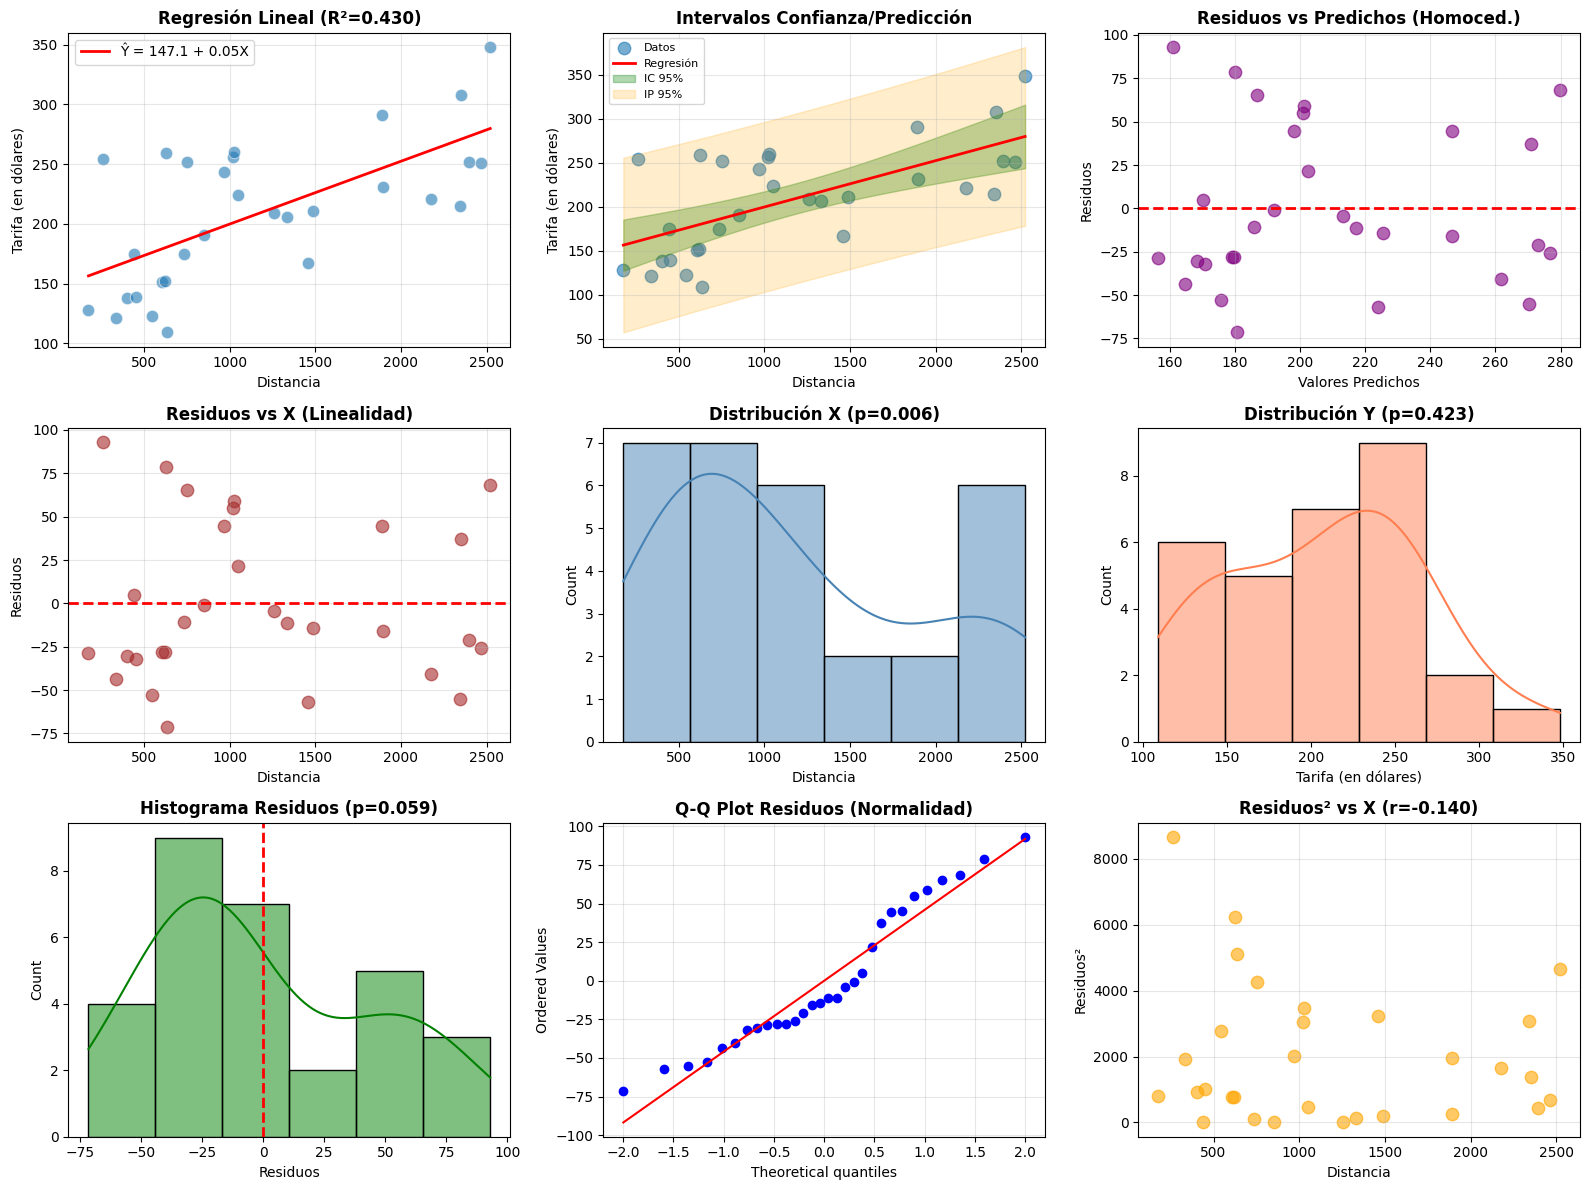


✓ ANÁLISIS COMPLETADO


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist, levene
from scipy import stats
import numpy as np

# --- DATOS DEL PROBLEMA (VUELOS AÉREOS) ---
data = {
    'Origen': ['Detroit, MI', 'Las Vegas, NV', 'Atlanta, GA', 'Chicago, IL', 'Fort Lauderdale, FL', 'Filadelfia, PA', 'Houston, TX', 'Baltimore, MD', 'Boston, MA', 'Kansas City, MO', 'Phoenix, AZ', 'Houston, TX', 'Burbank, CA', 'Atlanta, GA', 'Minneapolis, MN', 'Myrtle Beach, SC', 'Filadelfia, PA', 'Orlando, FL', 'Covington, KY', 'Los Ángeles, CA', 'Indianapolis, IN', 'San Francisco, CA', 'Columbus, OH', 'San Diego, CA', 'Washington, DC', 'St. Louis, MO', 'Seattle, WA', 'San Diego, CA', 'Nueva York, NY', 'Portland, ME'],
    'Destino': ['Baltimore, MD', 'Sacramento, CA', 'Boston, MA', 'Columbus, OH', 'Chicago, IL', 'Fort Lauderdale, FL', 'Houston, TX', 'Kansas City, MO', 'Milwaukee, WI', 'Portland, OR', 'Baltimore, MD', 'Houston, TX', 'Atlanta, GA', 'Minneapolis, MN', 'Nueva Orleans, LA', 'Sacramento, CA', 'Seattle, WA', 'Miami, FL', 'Minneapolis, MN', 'RaleighyDurham, NC', 'MidlandyOdessa, TX', 'DallasyFt.Worth, TX', 'Covington, KY', 'Phoenix, AZ', 'San José, CA', 'Orlando, FL', 'Nueva York, NY', 'West Palm Beach, FL', 'Seattle, WA', 'Washington, DC'],
    'Distancia': [636, 2395, 2176, 605, 403, 1258, 264, 627, 2342, 177, 2521, 1050, 441, 1021, 336, 752, 1333, 1460, 2350, 621, 737, 853, 1894, 2465, 1891, 1028, 545, 1489, 452, 969],
    'Tarifa (en dólares)': ['$109', '252', '221', '151', '138', '209', '254', '259', '215', '128', '348', '224', '175', '256', '121', '252', '206', '167', '308', '152', '175', '191', '231', '251', '291', '260', '123', '211', '139', '243']
}
df = pd.DataFrame(data)

# Limpiar y convertir la columna 'Tarifa (en dólares)' a numérica
df['Tarifa (en dólares)'] = df['Tarifa (en dólares)'].replace({r'\$': ''}, regex=True).astype(float)

var_x = 'Distancia'
var_y = 'Tarifa (en dólares)'
n, alfa = len(df), 0.05

print("=" * 70)
print("        ANÁLISIS DE REGRESIÓN LINEAL - VUELOS AÉREOS")
print("=" * 70)
print(f"n={n} | α={alfa} | X={var_x} | Y={var_y}\n")

# --- ANÁLISIS DESCRIPTIVO ---
mean_x, mean_y = df[var_x].mean(), df[var_y].mean()
std_x, std_y = df[var_x].std(ddof=1), df[var_y].std(ddof=1)
min_x, max_x = df[var_x].min(), df[var_x].max()
min_y, max_y = df[var_y].min(), df[var_y].max()

# Correlaciones y Normalidad
pearson = df[var_x].corr(df[var_y])
spearman = df[var_x].corr(df[var_y], method='spearman')
shapiro_x = shapiro(df[var_x])
shapiro_y = shapiro(df[var_y])

print("--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---")
print(f"X: μ={mean_x:.2f}, σ={std_x:.2f}, rango=[{min_x}, {max_x}] (millas)")
print(f"Y: μ={mean_y:.2f}, σ={std_y:.2f}, rango=[{min_y}, {max_y}] (dólares)")
print(f"\nNormalidad (Shapiro-Wilk):")
print(f"  X: p={shapiro_x.pvalue:.4f} {'✓ Normal' if shapiro_x.pvalue > alfa else '✗ No normal'}")
print(f"  Y: p={shapiro_y.pvalue:.4f} {'✓ Normal' if shapiro_y.pvalue > alfa else '✗ No normal'}")
print(f"\nCorrelación: Pearson={pearson:.4f} | Spearman={spearman:.4f}")
print(f"Magnitud: {'Fuerte' if abs(pearson) > 0.7 else 'Moderada' if abs(pearson) > 0.4 else 'Débil'} | Dirección: {'Positiva' if pearson > 0 else 'Negativa'}")

# --- PRUEBA DE HIPÓTESIS PARA CORRELACIÓN (Parte b) ---
gl = n - 2
t_corr = pearson * np.sqrt(n - 2) / np.sqrt(1 - pearson**2)
p_corr = t.sf(abs(t_corr), gl) * 2
t_crit_corr = t.ppf(1 - alfa/2, gl)

print(f"\n--- PRUEBA DE CORRELACIÓN ---")
print(f"H₀: ρ=0 vs H₁: ρ≠0 | t={t_corr:.3f}, t_crit=±{t_crit_corr:.3f}, p={p_corr:.4f}")
if p_corr < alfa:
    if pearson > 0:
        print(f"Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA y positiva (ρ > 0).")
        print(f"   Es razonable concluir que el coeficiente de correlación es mayor a cero.")
    else:
        print(f"Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA pero no positiva.")
else:
    print(f"Decisión: ✗ No rechazar H₀ - No hay evidencia de correlación significativa.")

# --- REGRESIÓN Y PRUEBAS ---
b1 = pearson * (std_y / std_x)
b0 = mean_y - b1 * mean_x
df['y_pred'] = b0 + b1 * df[var_x]
df['residuos'] = df[var_y] - df['y_pred']

# Errores y pruebas
SSE = ((df[var_y] - df['y_pred']) ** 2).sum()
SS_Total = ((df[var_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE
s_yx = np.sqrt(SSE / (n - 2))
suma_desv_x = ((df[var_x] - mean_x) ** 2).sum()
s_b = s_yx / np.sqrt(suma_desv_x)
r2 = 1 - (SSE / SS_Total) # Parte c

# Estadísticos t y F
t_calc = b1 / s_b
p_val_t = t.sf(abs(t_calc), gl) * 2  # dos colas
t_crit_pend = t.ppf(1 - alfa/2, gl)
F_calc = (SSR / 1) / (SSE / gl)
p_val_f = f_dist.sf(F_calc, 1, gl)

print(f"\n--- MODELO DE REGRESIÓN (Parte d) ---")
print(f"Ecuación: Ŷ = {b0:.4f} + {b1:.4f}X")
print(f"  b₀ (intersección): {b0:.4f} → Tarifa base esperada (dólares) cuando la distancia es 0.")
print(f"  b₁ (pendiente): {b1:.4f} → Por cada milla adicional, la tarifa aumenta en {b1:.4f} dólares.")

print(f"\nEstimación de tarifa para un vuelo de 1,000 millas:")
fare_1000_miles = b0 + b1 * 1000
print(f"  Tarifa estimada para 1,000 millas: ${fare_1000_miles:.2f}")

print(f"\nBondad de ajuste (Parte c):")
print(f"  R² = {r2:.4f} ({r2*100:.1f}% de la variabilidad en la Tarifa es explicada por la Distancia)")
print(f"  Error estándar (s_y,x) = {s_yx:.4f}")

print(f"\n--- PRUEBAS DE SIGNIFICANCIA (α={alfa}) ---")
print(f"1. Pendiente: H₀: β=0 vs H₁: β≠0")
print(f"   t={t_calc:.3f}, t_crit=±{t_crit_pend:.3f}, p={p_val_t:.4f}")
print(f"   → {'✓ Pendiente SIGNIFICATIVA' if p_val_t < alfa else '✗ Pendiente NO significativa'}")
print(f"\n2. Modelo (ANOVA): H₀: modelo no significativo vs H₁: modelo significativo")
print(f"   F={F_calc:.3f}, p={p_val_f:.6f}")
print(f"   → {'✓ Modelo SIGNIFICATIVO' if p_val_f < alfa else '✗ Modelo NO significativo'}")

# --- TABLA ANOVA ---
print(f"\n--- TABLA ANOVA ---")
print(f"{'Fuente':<12} {'SS':<12} {'gl':<6} {'MS':<12} {'F':<10} {'p-valor':<10}")
print("-" * 62)
print(f"{'Regresión':<12} {SSR:<12.4f} {1:<6} {SSR:<12.4f} {F_calc:<10.3f} {p_val_f:<10.6f}")
print(f"{'Error':<12} {SSE:<12.4f} {gl:<6} {SSE/gl:<12.4f}")
print(f"{'Total':<12} {SS_Total:<12.4f} {n-1:<6}")

# --- SUPUESTOS DEL MODELO ---
print(f"\n{'='*70}")
print("--- VALIDACIÓN DE SUPUESTOS DEL MODELO ---")
print(f"{'='*70}")

# 1. LINEALIDAD (visual - revisar gráfico)
print(f"\n1. LINEALIDAD:")
print(f"   • Correlación alta sugiere relación lineal: r={pearson:.4f}")
print(f"   • Revisar diagrama de dispersión para confirmar")
print(f"   → {'✓ Supuesto plausible' if abs(pearson) > 0.5 else '⚠ Revisar gráfico - correlación débil'}")

# 2. INDEPENDENCIA (no se puede probar con estos datos transversales)
print(f"\n2. INDEPENDENCIA:")
print(f"   • No hay orden temporal en los datos")
print(f"   • Asumimos observaciones independientes entre rutas.")
print(f"   → ✓ Supuesto asumido (datos transversales)")

# 3. NORMALIDAD DE RESIDUOS
shapiro_res = shapiro(df['residuos'])
print(f"\n3. NORMALIDAD DE RESIDUOS:")
print(f"   • Shapiro-Wilk: W={shapiro_res.statistic:.4f}, p={shapiro_res.pvalue:.4f}")
print(f"   • Media residuos: {df['residuos'].mean():.4f} (debe ≈ 0)")
print(f"   → {'✓ Residuos normales' if shapiro_res.pvalue > alfa else '⚠ Residuos NO normales'}")

# 4. HOMOCEDASTICIDAD (varianza constante)
df['res_std'] = df['residuos'] / s_yx
# Prueba de Breusch-Pagan simplificada: correlación entre residuos² y X
residuos_cuadrados = df['residuos'] ** 2
corr_hetero = df[var_x].corr(residuos_cuadrados)
# Dividir en dos grupos y aplicar Levene
mediana_x = df[var_x].median()
grupo1 = df[df[var_x] <= mediana_x]['residuos'].abs()
grupo2 = df[df[var_x] > mediana_x]['residuos'].abs()
levene_stat, levene_p = levene(grupo1, grupo2)

print(f"\n4. HOMOCEDASTICIDAD (varianza constante):")
print(f"   • Test de Levene: W={levene_stat:.4f}, p={levene_p:.4f}")
print(f"   • Correlación |residuos| vs X: {corr_hetero:.4f}")
print(f"   • Revisar gráfico 'Residuos vs Predichos' (debe ser aleatorio)")
if levene_p > alfa and abs(corr_hetero) < 0.3:
    print(f"   → ✓ Homocedasticidad cumplida")
elif levene_p <= alfa:
    print(f"   → ⚠ Posible heterocedasticidad detectada (p-value de Levene = {levene_p:.4f})")
else:
    print(f"   → ⚠ Revisar gráficamente - correlación moderada entre residuos² y X.")

# 5. OUTLIERS
outliers = df[np.abs(df['res_std']) > 2.5]
print(f"\n5. VALORES ATÍPICOS (OUTLIERS):")
print(f"   • Outliers (|res_std| > 2.5): {len(outliers)}/{n} ({len(outliers)/n*100:.1f}%)")
if len(outliers) > 0:
    for idx, row in outliers.iterrows():
        print(f"     • {row['Origen']} a {row['Destino']}: res_std={row['res_std']:.2f}")
print(f"   → {'✓ Sin outliers significativos' if len(outliers) == 0 else '⚠ Revisar outliers identificados'}")

# --- RESUMEN DE SUPUESTOS ---
supuestos_ok = (
    abs(pearson) > 0.5 and
    shapiro_res.pvalue > alfa and
    (levene_p > alfa and abs(corr_hetero) < 0.3) and # Check both Levene and residual-squared correlation
    len(outliers) <= n * 0.15
)

print(f"\n{'='*70}")
print(f"RESUMEN DE SUPUESTOS: {'✓ TODOS CUMPLIDOS' if supuestos_ok else '⚠ REVISAR SUPUESTOS'}")
print(f"{'='*70}")

# --- INTERVALOS (ejemplos) ---
t_crit = t.ppf(1 - alfa/2, gl)
x_ejemplos = [600, 1000, 2000, 2500] # Ejemplos adaptados a las distancias de vuelos

print(f"\n--- INTERVALOS DE CONFIANZA Y PREDICCIÓN (95%) ---")
print(f"{'X (Millas)':<12} {'Ŷ (Tarifa)':<12} {'IC Media':<25} {'IP Individual':<25}")
print("-" * 78)

for x_val in x_ejemplos:
    y_pred = b0 + b1 * x_val

    # IC para la media
    error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_conf = t_crit * s_yx * error_conf
    ic_inf, ic_sup = y_pred - margen_conf, y_pred + margen_conf

    # IP individual
    error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_pred = t_crit * s_yx * error_pred
    ip_inf, ip_sup = y_pred - margen_pred, y_pred + margen_pred

    print(f"{x_val:<12.0f} {y_pred:<12.2f} [{ic_inf:.1f}, {ic_sup:.1f}]{'':>10} [{ip_inf:.1f}, {ip_sup:.1f}]")

# --- EVALUACIÓN DE TRANSFORMACIÓN ---
print(f"\n--- ¿NECESITA TRANSFORMACIÓN DE DATOS? ---")
necesita = False
razones = []

if shapiro_x.pvalue <= alfa or shapiro_y.pvalue <= alfa:
    razones.append("Variables originales no normales")
    necesita = True
if shapiro_res.pvalue <= alfa:
    razones.append("Residuos no normales")
    necesita = True
if levene_p <= alfa or abs(corr_hetero) >= 0.3: # Using the updated heteroscedasticity check
    razones.append("Posible heterocedasticidad")
    necesita = True
if abs(pearson) < 0.5:
    razones.append(f"Correlación débil (r={pearson:.3f})")
    necesita = True
if len(outliers) > n * 0.15:
    razones.append(f"Exceso de outliers ({len(outliers)})")
    necesita = True

if necesita:
    print("⚠ CONSIDERAR TRANSFORMACIÓN:")
    for r in razones:
        print(f"  • {r}")
    print("\n  Transformaciones sugeridas:")
    print("    - log(Y): reduce asimetría positiva, estabiliza varianza")
    print("    - √Y: para datos de conteo con varianza proporcional a media")
    print("    - 1/Y: para relaciones no lineales decrecientes")
    print("    - Box-Cox: encuentra transformación óptima automáticamente")
else:
    print("✓ NO NECESARIA - Todos los supuestos cumplidos adecuadamente")

# --- RESUMEN EJECUTIVO ---
print(f"\n{'='*70}")
print("                        RESUMEN EJECUTIVO")
print(f"{'='*70}")
print(f"""
📊 MODELO: Ŷ = {b0:.2f} + {b1:.3f}X
   Interpretación: Por cada milla adicional → +{b1:.3f} dólares en la tarifa.

📈 BONDAD DE AJUSTE:
   • R² = {r2:.3f} ({r2*100:.1f}% de la variabilidad en la Tarifa explicada por la Distancia)
   • Correlación {'fuerte' if abs(pearson) > 0.7 else 'moderada' if abs(pearson) > 0.4 else 'débil'}: r = {pearson:.3f}
   • Error típico de predicción: ±{s_yx:.2f} dólares

✅ SIGNIFICANCIA ESTADÍSTICA:
   • Correlación: {'✓ Significativa' if p_corr < alfa else '✗ No significativa'} (p={p_corr:.4f})
   • Pendiente: {'✓ Significativa' if p_val_t < alfa else '✗ No significativa'} (p={p_val_t:.4f})
   • Modelo: {'✓ Significativo' if p_val_f < alfa else '✗ No significativo'} (p={p_val_f:.6f})

🔍 VALIDACIÓN DE SUPUESTOS:
   • Linealidad: {'✓' if abs(pearson) > 0.5 else '⚠'} (Revisar diagrama de dispersión)
   • Independencia: ✓ (Asumido en datos transversales)
   • Normalidad residuos: {'✓' if shapiro_res.pvalue > alfa else '⚠'} (p={shapiro_res.pvalue:.3f})
   • Homocedasticidad: {'✓' if levene_p > alfa and abs(corr_hetero) < 0.3 else '⚠'} (Levene p={levene_p:.3f})
   • Outliers: {len(outliers)}/{n} → {'✓ Aceptable' if len(outliers) <= n*0.15 else '⚠ Revisar'}

💡 CONCLUSIÓN:""")

if p_val_t < alfa and p_val_f < alfa and supuestos_ok:
    print(f"""   ✓✓ EL MODELO ES VÁLIDO Y CONFIABLE PARA PREDICCIONES

   El modelo cumple todos los supuestos y las pruebas estadísticas confirman
   que la distancia es un predictor significativo de la tarifa. Se recomienda IMPLEMENTAR
   este modelo para:
   • Estimación de tarifas para vuelos domésticos dentro del rango de distancias observadas.
   • Análisis de la estructura de costos basada en la distancia.
""")
elif p_val_t < alfa and p_val_f < alfa:
    print(f"""   ⚠ MODELO SIGNIFICATIVO pero con SUPUESTOS COMPROMETIDOS

   Aunque las pruebas de significancia son positivas, algunos supuestos no se cumplen
   completamente (ej., heterocedasticidad). Usar el modelo con PRECAUCIÓN y considerar:
   • Transformación de datos (ver recomendaciones arriba) para intentar cumplir los supuestos.
   • Recolectar más observaciones o investigar las causas de la heterocedasticidad.
   • Entender que las predicciones pueden ser menos precisas en ciertos rangos de distancia.
""")
else:
    print(f"""   ✗ MODELO CON LIMITACIONES SIGNIFICATIVAS

   El modelo NO es estadísticamente confiable. Se recomienda:
   • Recolectar más datos o mejorar calidad de datos.
   • Considerar otras variables explicativas que puedan influir en la tarifa (ej. aerolínea, clase, demanda).
   • Explorar modelos alternativos (no lineal, multivariado).
""")

print("\n" + "=" * 70)

# --- GRÁFICOS ---
fig = plt.figure(figsize=(16, 12))

# 1. Dispersión con regresión
ax1 = plt.subplot(3, 3, 1)
sns.scatterplot(x=var_x, y=var_y, data=df, s=80, alpha=0.6)
x_line = np.linspace(df[var_x].min(), df[var_x].max(), 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, 'r-', lw=2, label=f'Ŷ = {b0:.1f} + {b1:.2f}X')
plt.title(f'Regresión Lineal (R²={r2:.3f})', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend()
plt.grid(alpha=0.3)

# 2. Regresión con intervalos
ax2 = plt.subplot(3, 3, 2)
plt.scatter(df[var_x], df[var_y], s=80, alpha=0.6, label='Datos')
plt.plot(x_line, y_line, 'r-', lw=2, label='Regresión')

# Calcular bandas
ic_lower, ic_upper = [], []
ip_lower, ip_upper = [], []
for x_val in x_line:
    y_p = b0 + b1 * x_val
    e_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    e_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    ic_lower.append(y_p - t_crit * s_yx * e_conf)
    ic_upper.append(y_p + t_crit * s_yx * e_conf)
    ip_lower.append(y_p - t_crit * s_yx * e_pred)
    ip_upper.append(y_p + t_crit * s_yx * e_pred)

plt.fill_between(x_line, ic_lower, ic_upper, alpha=0.3, color='green', label='IC 95%')
plt.fill_between(x_line, ip_lower, ip_upper, alpha=0.2, color='orange', label='IP 95%')
plt.title('Intervalos Confianza/Predicción', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 3. Residuos vs Predichos (HOMOCEDASTICIDAD)
ax3 = plt.subplot(3, 3, 3)
plt.scatter(df['y_pred'], df['residuos'], s=80, alpha=0.6, color='purple')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs Predichos (Homoced.)', fontweight='bold')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 4. Residuos vs X
ax4 = plt.subplot(3, 3, 4)
plt.scatter(df[var_x], df['residuos'], s=80, alpha=0.6, color='brown')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs X (Linealidad)', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 5. Histograma X
ax5 = plt.subplot(3, 3, 5)
sns.histplot(df[var_x], kde=True, color='steelblue')
plt.title(f'Distribución X (p={shapiro_x.pvalue:.3f})', fontweight='bold')
plt.xlabel(var_x)

# 6. Histograma Y
ax6 = plt.subplot(3, 3, 6)
sns.histplot(df[var_y], kde=True, color='coral')
plt.title(f'Distribución Y (p={shapiro_y.pvalue:.3f})', fontweight='bold')
plt.xlabel(var_y)

# 7. Histograma Residuos
ax7 = plt.subplot(3, 3, 7)
sns.histplot(df['residuos'], kde=True, color='green')
plt.axvline(0, color='r', linestyle='--', lw=2)
plt.title(f'Histograma Residuos (p={shapiro_res.pvalue:.3f})', fontweight='bold')
plt.xlabel('Residuos')

# 8. Q-Q Plot Residuos
ax8 = plt.subplot(3, 3, 8)
stats.probplot(df['residuos'], dist="norm", plot=ax8)
plt.title('Q-Q Plot Residuos (Normalidad)', fontweight='bold')
plt.grid(alpha=0.3)

# 9. Gráfico de dispersión de residuos² vs X (Heterocedasticidad visual)
ax9 = plt.subplot(3, 3, 9)
plt.scatter(df[var_x], residuos_cuadrados, s=80, alpha=0.6, color='orange')
plt.title(f'Residuos² vs X (r={corr_hetero:.3f})', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos²')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ ANÁLISIS COMPLETADO")